# RAS Model Validation — Russia-Ukraine War (2022–2023)

Validate the RAS (Iterative Proportional Fitting) model against the **real-world shock** of the Russia-Ukraine conflict:

| Step | Description |
|------|-------------|
| **Baseline** | FAOSTAT avg 2014–2018 → T₀, P_baseline, C_baseline |
| **Actual post-shock** | Real FAOSTAT 2022–2023 → P_actual, C_actual, T_actual |
| **RAS prediction** | Feed actual P + baseline T₀ into RAS → predicted trade X_ras |
| **Compare** | How well does RAS predict the actual trade redistribution? |

**Nutrients:** N, P₂O₅, K₂O  
**Shock countries:** Russia, Belarus, Ukraine

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_rows', 30)

## 1. Load FAOSTAT Data — Baseline (2014–2018) & Post-Shock (2022–2023)

We load two periods from the same FAOSTAT datasets:
- **Baseline**: average 2014–2018 (pre-war steady state)
- **Post-shock**: average 2022–2023 (after the Russian invasion of Ukraine, Feb 2022)

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════════════
BASELINE_YEARS = list(range(2014, 2019))
POST_YEARS     = [2022, 2023]
MIN_THRESHOLD  = 1000  # tonnes — minimum P or C to include a country

NUTRIENT_CODES = {'N': 3102, 'P': 3103, 'K': 3104}
NUTRIENT_NAMES = {'N': 'Nitrogen (N)', 'P': 'Phosphate (P₂O₅)', 'K': 'Potash (K₂O)'}
ELEMENT_CODES  = {'Production': 5510, 'Import': 5610, 'Export': 5910, 'AgUse': 5157}

SHOCK_COUNTRIES = ['Russian Federation', 'Belarus', 'Ukraine']

# ══════════════════════════════════════════════════════════════════════════════
# Helper: average a set of year columns for a given item/element
# ══════════════════════════════════════════════════════════════════════════════
def load_series(df, item_code, elem_code, ycols):
    mask = (df['Item Code'] == item_code) & (df['Element Code'] == elem_code)
    sub = df.loc[mask, ['Area'] + ycols].copy()
    for c in ycols:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')
    sub['avg'] = sub[ycols].mean(axis=1)
    return sub.groupby('Area')['avg'].sum()

def load_trade_matrix(df, item_code, elem_code, ycols):
    ycols_avail = [c for c in ycols if c in df.columns]
    mask = (df['Item Code'] == item_code) & (df['Element Code'] == elem_code)
    sub = df.loc[mask, ['Reporter Countries', 'Partner Countries'] + ycols_avail].copy()
    for c in ycols_avail:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')
    sub['avg'] = sub[ycols_avail].mean(axis=1)
    flows = sub[['Reporter Countries', 'Partner Countries', 'avg']].dropna(subset=['avg'])
    flows = flows[flows['avg'] > 0]
    return flows.pivot_table(
        index='Reporter Countries', columns='Partner Countries',
        values='avg', aggfunc='sum', fill_value=0
    )

# ══════════════════════════════════════════════════════════════════════════════
# Load CSVs
# ══════════════════════════════════════════════════════════════════════════════
print("Loading inputs data...")
df_inputs = pd.read_csv(
    'Data/Inputs_FertilizersNutrient_E_All_Data/Inputs_FertilizersNutrient_E_All_Data_NOFLAG.csv',
    low_memory=False
)
print(f"  {len(df_inputs):,} rows")

print("Loading bilateral trade data (large file, may take ~30s)...")
df_trade = pd.read_csv(
    'Data/Fertilizers_DetailedTradeMatrix_E_All_Data/Fertilizers_DetailedTradeMatrix_E_All_Data_NOFLAG.csv',
    low_memory=False
)
print(f"  {len(df_trade):,} rows")

# ══════════════════════════════════════════════════════════════════════════════
# Build baseline (2014–2018) and post-shock (2022–2023) datasets
# ══════════════════════════════════════════════════════════════════════════════
base_ycols = [f'Y{y}' for y in BASELINE_YEARS]
post_ycols = [f'Y{y}' for y in POST_YEARS]

P_base_all, C_base_all, T0_base_all = {}, {}, {}
P_post_all, C_post_all, T_post_all  = {}, {}, {}

for nut, ic in NUTRIENT_CODES.items():
    P_base_all[nut] = load_series(df_inputs, ic, ELEMENT_CODES['Production'], base_ycols)
    C_base_all[nut] = load_series(df_inputs, ic, ELEMENT_CODES['AgUse'],      base_ycols)
    T0_base_all[nut] = load_trade_matrix(df_trade, ic, ELEMENT_CODES['Export'], base_ycols)

    P_post_all[nut] = load_series(df_inputs, ic, ELEMENT_CODES['Production'], post_ycols)
    C_post_all[nut] = load_series(df_inputs, ic, ELEMENT_CODES['AgUse'],      post_ycols)
    T_post_all[nut] = load_trade_matrix(df_trade, ic, ELEMENT_CODES['Export'], post_ycols)

print("\n── Data Summary ──")
print(f"{'Nutrient':20s} {'Baseline producers':>20s} {'Post-shock producers':>22s} {'Baseline T0':>14s} {'Post-shock T':>14s}")
print("─" * 95)
for nut in ['N', 'P', 'K']:
    bp = (P_base_all[nut] > 1000).sum()
    pp = (P_post_all[nut] > 1000).sum()
    bs = T0_base_all[nut].shape
    ps = T_post_all[nut].shape
    print(f"{NUTRIENT_NAMES[nut]:20s} {bp:>20d} {pp:>22d} {bs[0]:>5d}×{bs[1]:<5d}  {ps[0]:>5d}×{ps[1]:<5d}")

Loading inputs data...
  5,287 rows
Loading bilateral trade data (large file, may take ~30s)...
  654,399 rows

── Data Summary ──
Nutrient               Baseline producers   Post-shock producers    Baseline T0   Post-shock T
───────────────────────────────────────────────────────────────────────────────────────────────
Nitrogen (N)                          108                    104   184×235      173×232  
Phosphate (P₂O₅)                       88                     82   173×231      162×227  
Potash (K₂O)                           48                     47   174×233      165×228  


## 2. The Real Shock — What Actually Happened to Production?

Before running the model, let's see the **actual** production changes for Russia, Belarus, and Ukraine between the baseline (2014–2018) and post-shock (2022–2023) periods.

In [3]:
for nut in ['N', 'P', 'K']:
    P_b = P_base_all[nut]
    P_p = P_post_all[nut]
    C_b = C_base_all[nut]
    C_p = C_post_all[nut]

    print(f"══ {NUTRIENT_NAMES[nut]} — Production Change ══\n")
    print(f"{'Country':40s} {'Baseline (t)':>14s} {'2022-23 (t)':>14s} {'Change (t)':>14s} {'Change %':>10s}")
    print("─" * 95)
    for c in SHOCK_COUNTRIES:
        base = P_b.get(c, 0)
        post = P_p.get(c, 0)
        chg = post - base
        pct = (chg / base * 100) if base > 0 else 0
        print(f"{c:40s} {base:>14,.0f} {post:>14,.0f} {chg:>+14,.0f} {pct:>+9.1f}%")
    g_b, g_p = P_b.sum(), P_p.sum()
    print(f"{'Global total':40s} {g_b:>14,.0f} {g_p:>14,.0f} {g_p-g_b:>+14,.0f} {(g_p/g_b-1)*100:>+9.1f}%")

    print(f"\n{'Country':40s} {'Demand base':>14s} {'Demand 22-23':>14s} {'Change %':>10s}")
    print("─" * 80)
    for c in SHOCK_COUNTRIES:
        base = C_b.get(c, 0)
        post = C_p.get(c, 0)
        pct = ((post / base - 1) * 100) if base > 0 else 0
        print(f"{c:40s} {base:>14,.0f} {post:>14,.0f} {pct:>+9.1f}%")
    print()

══ Nitrogen (N) — Production Change ══

Country                                    Baseline (t)    2022-23 (t)     Change (t)   Change %
───────────────────────────────────────────────────────────────────────────────────────────────
Russian Federation                            9,379,500     12,195,750     +2,816,250     +30.0%
Belarus                                         854,078        958,943       +104,865     +12.3%
Ukraine                                       1,324,017              0     -1,324,017    -100.0%
Global total                                535,894,909    540,989,955     +5,095,045      +1.0%

Country                                     Demand base   Demand 22-23   Change %
────────────────────────────────────────────────────────────────────────────────
Russian Federation                            1,391,587      2,193,694     +57.6%
Belarus                                         412,019        476,736     +15.7%
Ukraine                                       1,194

## 3. RAS Algorithm

The same RAS (Iterative Proportional Fitting) function used in the general model. Finds trade matrix $X$ such that row sums = export targets, column sums = import targets, while preserving the structure of the baseline trade matrix $T_0$.

In [4]:
def run_ras(
    T0: pd.DataFrame,
    S_hat: pd.Series,
    D_hat: pd.Series,
    max_iter: int = 1_000,
    tol: float = 1e-6,
    verbose: bool = True
) -> pd.DataFrame:
    """RAS: find X where row sums = S_hat, col sums = D_hat, structure ≈ T0."""
    countries = T0.index.tolist()
    T = T0.to_numpy(copy=True).astype(float)
    s = S_hat.to_numpy(copy=True)
    d = D_hat.to_numpy(copy=True)
    r = np.ones(len(countries))
    c = np.ones(len(countries))

    for iteration in range(1, max_iter + 1):
        row_sums = (r[:, None] * T * c[None, :]).sum(axis=1)
        with np.errstate(invalid='ignore', divide='ignore'):
            r_new = np.where(row_sums > 0, r * s / row_sums, r)

        col_sums = (r_new[:, None] * T * c[None, :]).sum(axis=0)
        with np.errstate(invalid='ignore', divide='ignore'):
            c_new = np.where(col_sums > 0, c * d / col_sums, c)

        X_current = r_new[:, None] * T * c_new[None, :]
        row_err = np.abs(X_current.sum(axis=1) - s).max()
        col_err = np.abs(X_current.sum(axis=0) - d).max()
        max_err = max(row_err, col_err)
        r, c = r_new, c_new

        if max_err < tol:
            if verbose:
                print(f"  RAS converged in {iteration} iterations (max error = {max_err:.2e})")
            break
    else:
        print(f"  WARNING: RAS did not converge after {max_iter} iterations (max error = {max_err:.2e})")

    X_final = r[:, None] * T * c[None, :]
    return pd.DataFrame(X_final, index=countries, columns=countries)


def run_full_ras_pipeline(P_vec, C_vec, T0_mat, country_list):
    """Phase 1 (domestic filter) + Phase 2 (normalize) + Phase 3 (RAS) for a single scenario."""
    nc = len(country_list)
    K = pd.Series(np.zeros(nc), index=country_list)
    S = pd.Series(np.zeros(nc), index=country_list)
    D = pd.Series(np.zeros(nc), index=country_list)

    for i in country_list:
        bi = P_vec[i] - C_vec[i]
        if bi > 0:
            K[i], S[i], D[i] = C_vec[i], bi, 0
        else:
            K[i], S[i], D[i] = P_vec[i], 0, abs(bi)

    st, dt = S.sum(), D.sum()
    S_hat, D_hat = S.copy(), D.copy()
    if st < dt:
        D_hat = D * (st / dt)
    elif st > dt:
        S_hat = S * (dt / st)

    X = run_ras(T0_mat, S_hat, D_hat, verbose=False)
    return X, K

print("RAS functions defined.")

RAS functions defined.


## 4. Run RAS Predictions & Compare with Actual Trade

For the primary nutrient (Nitrogen), we run three scenarios:
1. **Baseline RAS**: baseline P & C → sanity check (reproduces 2014–2018)
2. **RAS predicted (actual P, baseline C)**: what RAS predicts if only production changes
3. **RAS predicted (actual P, actual C)**: what RAS predicts with both production and demand changes

Then compare with the **actual 2022–2023 trade flows** from FAOSTAT.

In [5]:
VAL_NUTRIENT = 'N'

P_b = P_base_all[VAL_NUTRIENT]
C_b = C_base_all[VAL_NUTRIENT]
P_a = P_post_all[VAL_NUTRIENT]
C_a = C_post_all[VAL_NUTRIENT]

# Union of all countries with significant activity in either period
all_c = sorted(set(P_b.index) | set(C_b.index) | set(P_a.index) | set(C_a.index))
P_b = P_b.reindex(all_c, fill_value=0).clip(lower=0)
C_b = C_b.reindex(all_c, fill_value=0).clip(lower=0)
P_a = P_a.reindex(all_c, fill_value=0).clip(lower=0)
C_a = C_a.reindex(all_c, fill_value=0).clip(lower=0)

mask = (P_b >= MIN_THRESHOLD) | (C_b >= MIN_THRESHOLD) | (P_a >= MIN_THRESHOLD) | (C_a >= MIN_THRESHOLD)
val_countries = sorted(P_b[mask].index)
val_n = len(val_countries)

P_b = P_b.reindex(val_countries, fill_value=0)
C_b = C_b.reindex(val_countries, fill_value=0)
P_a = P_a.reindex(val_countries, fill_value=0)
C_a = C_a.reindex(val_countries, fill_value=0)

# Baseline trade matrix (T0)
T0_base = T0_base_all[VAL_NUTRIENT].reindex(index=val_countries, columns=val_countries, fill_value=0)
_tv = T0_base.to_numpy(copy=True)
np.fill_diagonal(_tv, 0)
T0_base = pd.DataFrame(_tv, index=T0_base.index, columns=T0_base.columns)

# Actual post-shock trade matrix
T_act = T_post_all[VAL_NUTRIENT].reindex(index=val_countries, columns=val_countries, fill_value=0)
_tv2 = T_act.to_numpy(copy=True)
np.fill_diagonal(_tv2, 0)
T_act = pd.DataFrame(_tv2, index=T_act.index, columns=T_act.columns)

# ── Run 3 RAS scenarios ──
print(f"Running RAS scenarios for {NUTRIENT_NAMES[VAL_NUTRIENT]}...\n")

print("  Scenario 1: Baseline (2014-18 P & C)")
X_ras_base, K_base = run_full_ras_pipeline(P_b, C_b, T0_base, val_countries)

print("  Scenario 2: Actual 2022 production, baseline demand")
X_ras_pred, K_pred = run_full_ras_pipeline(P_a, C_b, T0_base, val_countries)

print("  Scenario 3: Actual 2022 production AND demand")
X_ras_pred2, K_pred2 = run_full_ras_pipeline(P_a, C_a, T0_base, val_countries)

print(f"\n══ RAS Validation — {NUTRIENT_NAMES[VAL_NUTRIENT]} ══")
print(f"Countries in validation: {val_n}\n")
print(f"{'Scenario':50s} {'Total Trade (t)':>18s}")
print("─" * 70)
print(f"{'Baseline RAS (2014-18 P & C)':50s} {X_ras_base.values.sum():>18,.0f}")
print(f"{'RAS predicted (actual P, baseline C)':50s} {X_ras_pred.values.sum():>18,.0f}")
print(f"{'RAS predicted (actual P, actual C)':50s} {X_ras_pred2.values.sum():>18,.0f}")
print(f"{'Actual 2022-23 trade':50s} {T_act.values.sum():>18,.0f}")

Running RAS scenarios for Nitrogen (N)...

  Scenario 1: Baseline (2014-18 P & C)
  Scenario 2: Actual 2022 production, baseline demand
  Scenario 3: Actual 2022 production AND demand

══ RAS Validation — Nitrogen (N) ══
Countries in validation: 194

Scenario                                              Total Trade (t)
──────────────────────────────────────────────────────────────────────
Baseline RAS (2014-18 P & C)                               25,411,379
RAS predicted (actual P, baseline C)                       22,582,061
RAS predicted (actual P, actual C)                         29,043,349
Actual 2022-23 trade                                       49,144,209


## 5. Country-Level Comparison: RAS Prediction vs Actual

Top importers and exporters: how close is the RAS prediction to reality?

In [6]:
X_pred = X_ras_pred2  # primary prediction: actual P & C

imp_pred   = X_pred.sum(axis=0)
imp_actual = T_act.sum(axis=0)
imp_base   = X_ras_base.sum(axis=0)

exp_pred   = X_pred.sum(axis=1)
exp_actual = T_act.sum(axis=1)
exp_base   = X_ras_base.sum(axis=1)

val_df = pd.DataFrame({
    'Imports_baseline': imp_base,
    'Imports_RAS':      imp_pred,
    'Imports_actual':   imp_actual,
    'Exports_baseline': exp_base,
    'Exports_RAS':      exp_pred,
    'Exports_actual':   exp_actual,
}, index=val_countries)
val_df = val_df[(val_df.abs() > 100).any(axis=1)]

val_df['Imp_RAS_err_%'] = ((val_df['Imports_RAS'] - val_df['Imports_actual']) /
                            val_df['Imports_actual'].clip(lower=1) * 100)
val_df['Exp_RAS_err_%'] = ((val_df['Exports_RAS'] - val_df['Exports_actual']) /
                            val_df['Exports_actual'].clip(lower=1) * 100)

print(f"══ Country-Level Validation — {NUTRIENT_NAMES[VAL_NUTRIENT]} ══\n")

print("── Top 15 importers: RAS prediction vs actual ──")
top_imp = val_df.nlargest(15, 'Imports_actual')
display(top_imp[['Imports_baseline', 'Imports_RAS', 'Imports_actual', 'Imp_RAS_err_%']].round(0))

print("\n── Top 15 exporters: RAS prediction vs actual ──")
top_exp = val_df.nlargest(15, 'Exports_actual')
display(top_exp[['Exports_baseline', 'Exports_RAS', 'Exports_actual', 'Exp_RAS_err_%']].round(0))

print(f"\n── Shocked countries detail ──")
for c in SHOCK_COUNTRIES:
    if c in val_df.index:
        row = val_df.loc[c]
        print(f"\n  {c}:")
        print(f"    Exports: baseline {row['Exports_baseline']:>12,.0f} → "
              f"RAS {row['Exports_RAS']:>12,.0f} → actual {row['Exports_actual']:>12,.0f}")
        print(f"    Imports: baseline {row['Imports_baseline']:>12,.0f} → "
              f"RAS {row['Imports_RAS']:>12,.0f} → actual {row['Imports_actual']:>12,.0f}")

══ Country-Level Validation — Nitrogen (N) ══

── Top 15 importers: RAS prediction vs actual ──


,Imports_baseline,Imports_RAS,Imports_actual,Imp_RAS_err_%
India,"3,919,540.0","3,908,550.0","5,557,693.0",-30.0
Brazil,"3,481,845.0","5,920,916.0","5,410,274.0",9.0
United States of America,"1,171,063.0",0.0,"3,862,231.0",-100.0
Australia,"1,027,458.0","1,677,847.0","1,761,646.0",-5.0
France,"1,828,444.0","1,702,715.0","1,726,863.0",-1.0
Türkiye,"769,451.0","795,711.0","1,429,398.0",-44.0
Thailand,"1,363,667.0","2,189,276.0","1,259,810.0",74.0
Canada,0.0,0.0,"1,243,727.0",-100.0
Mexico,"795,565.0","895,663.0","1,149,253.0",-22.0
Germany,"256,449.0","31,321.0","1,056,191.0",-97.0



── Top 15 exporters: RAS prediction vs actual ──


,Exports_baseline,Exports_RAS,Exports_actual,Exp_RAS_err_%
Russian Federation,"5,597,478.0","6,934,134.0","6,897,533.0",1.0
"China, mainland","4,411,123.0","4,575,913.0","5,997,531.0",-24.0
Qatar,"1,947,679.0","1,794,908.0","2,819,764.0",-36.0
Saudi Arabia,"1,578,640.0","2,198,801.0","2,587,524.0",-15.0
United States of America,0.0,"1,656,990.0","2,260,739.0",-27.0
Oman,"880,350.0","642,603.0","1,840,094.0",-65.0
Egypt,"1,138,582.0","1,559,513.0","1,821,087.0",-14.0
Nigeria,"40,468.0","801,014.0","1,540,571.0",-48.0
Algeria,"558,352.0","674,553.0","1,537,857.0",-56.0
Netherlands (Kingdom of the),"1,146,873.0","1,002,574.0","1,460,315.0",-31.0



── Shocked countries detail ──

  Russian Federation:
    Exports: baseline    5,597,478 → RAS    6,934,134 → actual    6,897,533
    Imports: baseline            0 → RAS            0 → actual       39,000

  Belarus:
    Exports: baseline      309,770 → RAS      334,300 → actual      118,864
    Imports: baseline            0 → RAS            0 → actual      107,732

  Ukraine:
    Exports: baseline       90,587 → RAS            0 → actual      353,052
    Imports: baseline            0 → RAS    1,103,960 → actual      456,454


## 6. Visualizations — RAS Prediction vs Actual

Four plots:
1. **Scatter: imports** — RAS predicted vs actual (each dot = one country)
2. **Scatter: exports** — same for exports
3. **Bar: shocked countries** — baseline vs RAS vs actual exports
4. **Bar: top importers** — same three-way comparison for the 10 largest importers

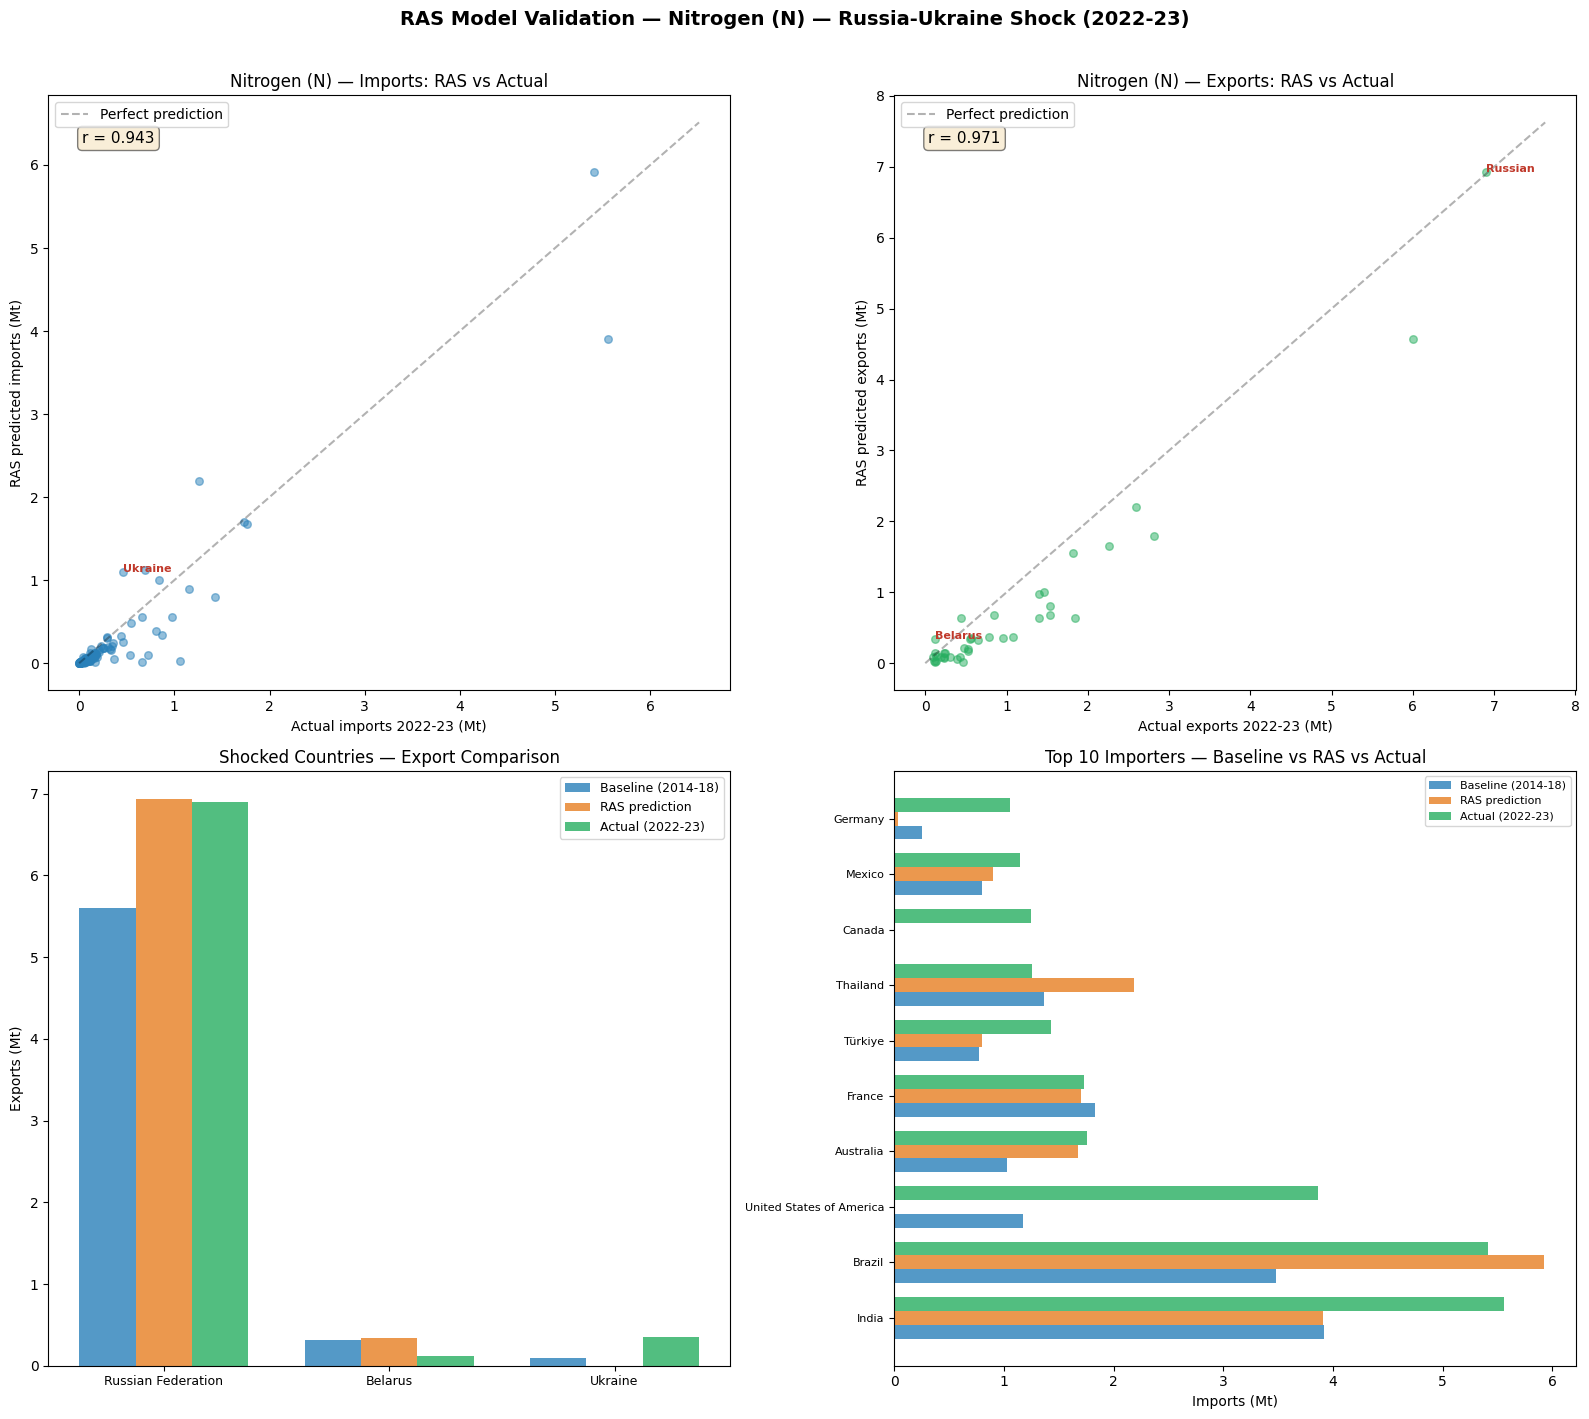


══ Validation Summary — Nitrogen (N) ══
  Import correlation (r):  0.9434
  Export correlation (r):  0.9714
  Import MAE:              116,397 t
  Export MAE:              369,274 t


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Scatter: predicted vs actual imports
ax = axes[0, 0]
mask_imp = (val_df['Imports_actual'] > 1000) & (val_df['Imports_RAS'] > 1000)
x = val_df.loc[mask_imp, 'Imports_actual'] / 1e6
y = val_df.loc[mask_imp, 'Imports_RAS'] / 1e6
ax.scatter(x, y, alpha=0.5, s=30, c='#2980b9')
lim = max(x.max(), y.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('Actual imports 2022-23 (Mt)')
ax.set_ylabel('RAS predicted imports (Mt)')
ax.set_title(f'{NUTRIENT_NAMES[VAL_NUTRIENT]} — Imports: RAS vs Actual')
ax.legend()
for c in SHOCK_COUNTRIES:
    if c in val_df.index and mask_imp.get(c, False):
        ax.annotate(c.split()[0], (x[c], y[c]), fontsize=8, color='#c0392b', fontweight='bold')
corr_imp = x.corr(y)
ax.text(0.05, 0.92, f'r = {corr_imp:.3f}', transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Scatter: predicted vs actual exports
ax2 = axes[0, 1]
mask_exp = (val_df['Exports_actual'] > 1000) & (val_df['Exports_RAS'] > 1000)
x2 = val_df.loc[mask_exp, 'Exports_actual'] / 1e6
y2 = val_df.loc[mask_exp, 'Exports_RAS'] / 1e6
ax2.scatter(x2, y2, alpha=0.5, s=30, c='#27ae60')
lim2 = max(x2.max(), y2.max()) * 1.1
ax2.plot([0, lim2], [0, lim2], 'k--', alpha=0.3, label='Perfect prediction')
ax2.set_xlabel('Actual exports 2022-23 (Mt)')
ax2.set_ylabel('RAS predicted exports (Mt)')
ax2.set_title(f'{NUTRIENT_NAMES[VAL_NUTRIENT]} — Exports: RAS vs Actual')
ax2.legend()
for c in SHOCK_COUNTRIES:
    if c in val_df.index and mask_exp.get(c, False):
        ax2.annotate(c.split()[0], (x2[c], y2[c]), fontsize=8, color='#c0392b', fontweight='bold')
corr_exp = x2.corr(y2)
ax2.text(0.05, 0.92, f'r = {corr_exp:.3f}', transform=ax2.transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Bar: shocked countries exports
ax3 = axes[1, 0]
sc_data = []
for c in SHOCK_COUNTRIES:
    if c in val_df.index:
        sc_data.append({
            'country': c.split('(')[0].strip()[:20],
            'baseline': val_df.loc[c, 'Exports_baseline'] / 1e6,
            'ras': val_df.loc[c, 'Exports_RAS'] / 1e6,
            'actual': val_df.loc[c, 'Exports_actual'] / 1e6,
        })
if sc_data:
    sc_df = pd.DataFrame(sc_data).set_index('country')
    x_pos = np.arange(len(sc_df))
    w = 0.25
    ax3.bar(x_pos - w, sc_df['baseline'], w, label='Baseline (2014-18)', color='#2980b9', alpha=0.8)
    ax3.bar(x_pos,     sc_df['ras'],      w, label='RAS prediction',     color='#e67e22', alpha=0.8)
    ax3.bar(x_pos + w, sc_df['actual'],   w, label='Actual (2022-23)',   color='#27ae60', alpha=0.8)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(sc_df.index, fontsize=9)
    ax3.set_ylabel('Exports (Mt)')
    ax3.set_title('Shocked Countries — Export Comparison')
    ax3.legend(fontsize=9)

# 4. Horizontal bar: top 10 importers
ax4 = axes[1, 1]
top10 = val_df.nlargest(10, 'Imports_actual')
x_pos4 = np.arange(len(top10))
w4 = 0.25
ax4.barh(x_pos4 - w4, top10['Imports_baseline'] / 1e6, w4,
         label='Baseline (2014-18)', color='#2980b9', alpha=0.8)
ax4.barh(x_pos4,      top10['Imports_RAS'] / 1e6,      w4,
         label='RAS prediction',     color='#e67e22', alpha=0.8)
ax4.barh(x_pos4 + w4, top10['Imports_actual'] / 1e6,   w4,
         label='Actual (2022-23)',   color='#27ae60', alpha=0.8)
ax4.set_yticks(x_pos4)
ax4.set_yticklabels([c[:25] for c in top10.index], fontsize=8)
ax4.set_xlabel('Imports (Mt)')
ax4.set_title('Top 10 Importers — Baseline vs RAS vs Actual')
ax4.legend(fontsize=8)

plt.suptitle(f'RAS Model Validation — {NUTRIENT_NAMES[VAL_NUTRIENT]} — Russia-Ukraine Shock (2022-23)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n══ Validation Summary — {NUTRIENT_NAMES[VAL_NUTRIENT]} ══")
print(f"  Import correlation (r):  {corr_imp:.4f}")
print(f"  Export correlation (r):  {corr_exp:.4f}")
imp_mae = (val_df.loc[mask_imp, 'Imports_RAS'] - val_df.loc[mask_imp, 'Imports_actual']).abs().mean()
exp_mae = (val_df.loc[mask_exp, 'Exports_RAS'] - val_df.loc[mask_exp, 'Exports_actual']).abs().mean()
print(f"  Import MAE:              {imp_mae:,.0f} t")
print(f"  Export MAE:              {exp_mae:,.0f} t")

## 7. Cross-Nutrient Validation (N, P₂O₅, K₂O)

Run the same validation for all three nutrients and compare performance.

In [8]:
print("══ Cross-Nutrient Validation Summary ══\n")
print(f"{'Nutrient':20s} {'r (imports)':>12s} {'r (exports)':>12s} {'MAE imp (t)':>14s} "
      f"{'MAE exp (t)':>14s} {'Trade RAS':>14s} {'Trade actual':>14s}")
print("─" * 105)

val_summary = {}
for nut in ['N', 'P', 'K']:
    P_bv = P_base_all[nut].reindex(val_countries, fill_value=0).clip(lower=0)
    C_bv = C_base_all[nut].reindex(val_countries, fill_value=0).clip(lower=0)
    P_av = P_post_all[nut].reindex(val_countries, fill_value=0).clip(lower=0)
    C_av = C_post_all[nut].reindex(val_countries, fill_value=0).clip(lower=0)

    T0v = T0_base_all[nut].reindex(index=val_countries, columns=val_countries, fill_value=0)
    _tvv = T0v.to_numpy(copy=True)
    np.fill_diagonal(_tvv, 0)
    T0v = pd.DataFrame(_tvv, index=T0v.index, columns=T0v.columns)

    Tav = T_post_all[nut].reindex(index=val_countries, columns=val_countries, fill_value=0)
    _tvv2 = Tav.to_numpy(copy=True)
    np.fill_diagonal(_tvv2, 0)
    Tav = pd.DataFrame(_tvv2, index=Tav.index, columns=Tav.columns)

    Xp, _ = run_full_ras_pipeline(P_av, C_av, T0v, val_countries)

    imp_p = Xp.sum(axis=0)
    imp_a = Tav.sum(axis=0)
    exp_p = Xp.sum(axis=1)
    exp_a = Tav.sum(axis=1)

    m_imp = (imp_p > 100) & (imp_a > 100)
    m_exp = (exp_p > 100) & (exp_a > 100)

    r_imp = imp_p[m_imp].corr(imp_a[m_imp]) if m_imp.sum() > 2 else float('nan')
    r_exp = exp_p[m_exp].corr(exp_a[m_exp]) if m_exp.sum() > 2 else float('nan')
    mae_imp = (imp_p[m_imp] - imp_a[m_imp]).abs().mean()
    mae_exp = (exp_p[m_exp] - exp_a[m_exp]).abs().mean()

    val_summary[nut] = {'r_imp': r_imp, 'r_exp': r_exp, 'mae_imp': mae_imp, 'mae_exp': mae_exp}

    print(f"{NUTRIENT_NAMES[nut]:20s} {r_imp:>12.4f} {r_exp:>12.4f} {mae_imp:>14,.0f} "
          f"{mae_exp:>14,.0f} {Xp.values.sum():>14,.0f} {Tav.values.sum():>14,.0f}")

══ Cross-Nutrient Validation Summary ══

Nutrient              r (imports)  r (exports)    MAE imp (t)    MAE exp (t)      Trade RAS   Trade actual
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Nitrogen (N)               0.9435       0.9716        114,509        365,877     29,043,349     49,144,209
Phosphate (P₂O₅)           0.9857       0.9864         41,416        210,196     14,669,296     21,774,029
Potash (K₂O)               0.9729       0.9683         70,610        570,141     28,976,900     39,064,419


## 8. Bilateral Flow Comparison — RAS vs Actual

The most granular test: compare individual country-to-country trade flows.

══ Top 20 Bilateral Flows — Nitrogen (N) ══

From                           To                                 Baseline     RAS pred       Actual    Error %
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
China, mainland                India                             1,724,875    1,876,837    1,230,222     +52.6%
Russian Federation             Brazil                            1,953,891    2,859,302    1,154,200    +147.7%
Russian Federation             India                               303,574      273,648    1,144,806     -76.1%
China, mainland                Brazil                              150,858      266,483    1,095,363     -75.7%
Russian Federation             United States of America            122,746            0      874,485    -100.0%
United States of America       Canada                                    0            0      717,252    -100.0%
Oman                           India                        

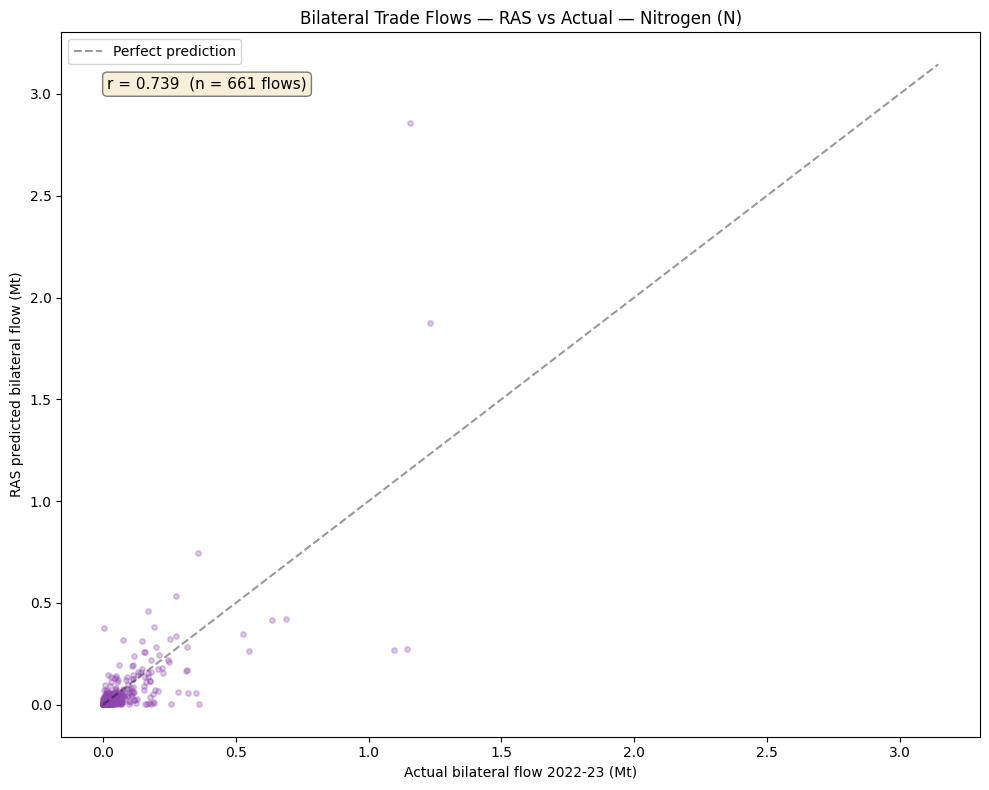


Bilateral flow correlation: r = 0.7387


In [9]:
def flatten_trade(matrix, label):
    rows = []
    for i in matrix.index:
        for j in matrix.columns:
            if i != j and matrix.loc[i, j] > 100:
                rows.append({'from': i, 'to': j, label: matrix.loc[i, j]})
    return pd.DataFrame(rows)

flat_pred = flatten_trade(X_pred, 'ras')
flat_act  = flatten_trade(T_act, 'actual')
flat_base = flatten_trade(X_ras_base, 'baseline')

merged = flat_act.merge(flat_pred, on=['from', 'to'], how='outer')
merged = merged.merge(flat_base, on=['from', 'to'], how='outer')
merged = merged.fillna(0)
merged = merged[(merged['actual'] > 1000) | (merged['ras'] > 1000)]

print(f"══ Top 20 Bilateral Flows — {NUTRIENT_NAMES[VAL_NUTRIENT]} ══\n")
top_flows = merged.nlargest(20, 'actual')
print(f"{'From':30s} {'To':30s} {'Baseline':>12s} {'RAS pred':>12s} {'Actual':>12s} {'Error %':>10s}")
print("─" * 110)
for _, r in top_flows.iterrows():
    err = ((r['ras'] - r['actual']) / max(r['actual'], 1)) * 100
    print(f"{r['from'][:29]:30s} {r['to'][:29]:30s} {r['baseline']:>12,.0f} "
          f"{r['ras']:>12,.0f} {r['actual']:>12,.0f} {err:>+9.1f}%")

# Scatter of all bilateral flows
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
m = merged[(merged['actual'] > 1000) & (merged['ras'] > 1000)]
ax.scatter(m['actual'] / 1e6, m['ras'] / 1e6, alpha=0.3, s=15, c='#8e44ad')
lim = max(m['actual'].max(), m['ras'].max()) / 1e6 * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Perfect prediction')
ax.set_xlabel('Actual bilateral flow 2022-23 (Mt)')
ax.set_ylabel('RAS predicted bilateral flow (Mt)')
ax.set_title(f'Bilateral Trade Flows — RAS vs Actual — {NUTRIENT_NAMES[VAL_NUTRIENT]}')
r_bilateral = m['actual'].corr(m['ras'])
ax.text(0.05, 0.92, f'r = {r_bilateral:.3f}  (n = {len(m)} flows)',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nBilateral flow correlation: r = {r_bilateral:.4f}")

## 9. Interpretation

- **Correlation (r)** close to 1 → RAS preserves the relative ranking of trade flows well
- **MAE** → average absolute error per country in tonnes
- **Scatter on diagonal** → perfect match between predicted and actual
- **Shocked countries bar chart** → shows whether RAS correctly predicts the export decline for Russia, Belarus, Ukraine

Key question: *Does the gravity-based redistribution from RAS match how real trade actually shifted after the war?*

### Limitations
- RAS assumes trade routes are "sticky" — it redistributes along existing routes proportionally
- In reality, new trade routes emerged (e.g., Russia → India) and sanctions created non-proportional disruptions
- Price effects and stockpiling are not modelled
- The 2022–2023 average may smooth out the initial chaos vs the new equilibrium